=== Task 2: First 5 Rows ===
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0 

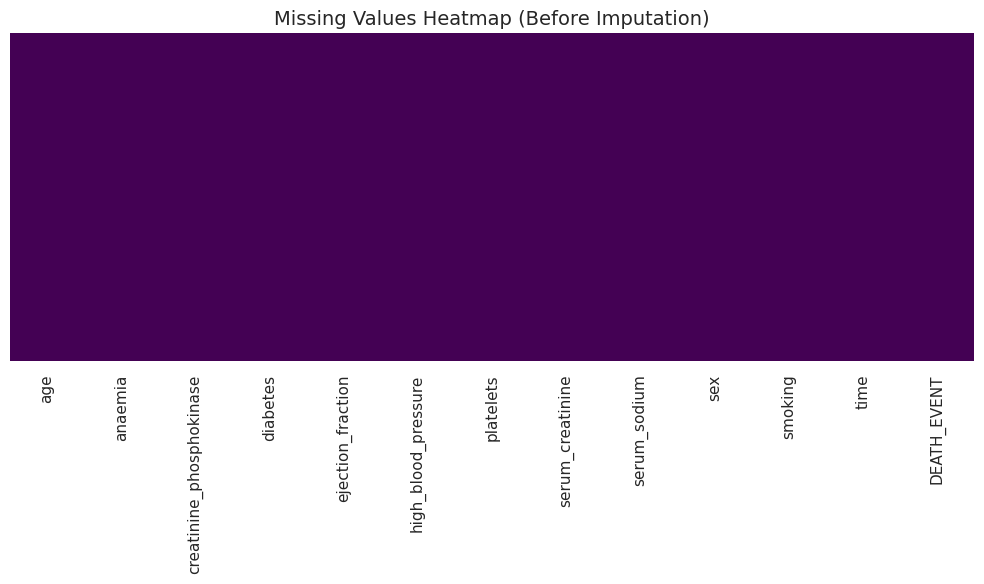

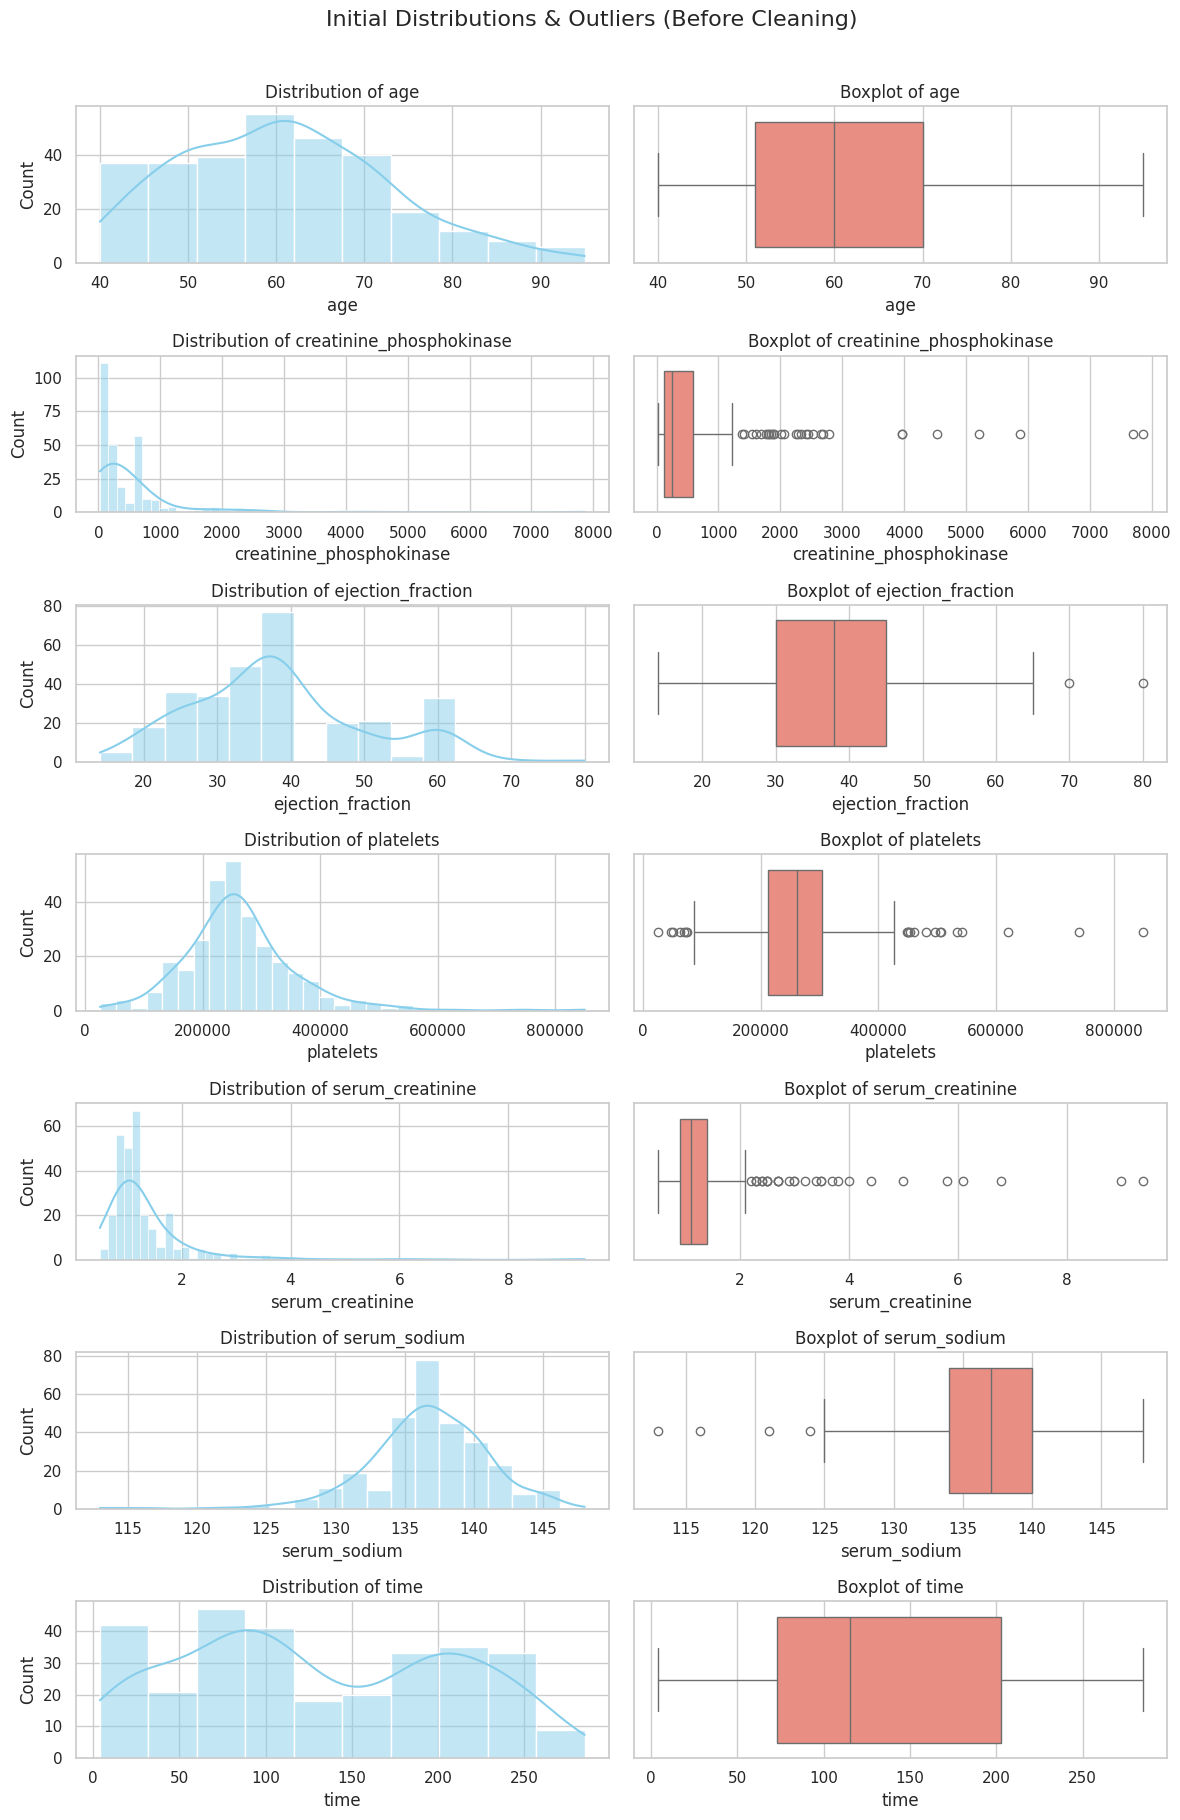

=== Task 8: Inconsistency Check ===
Invalid age entries (< 0): 0
=== Task 9: Engineered Features Sample ===
    age age_group  ejection_fraction  serum_creatinine  risk_score
0  75.0       >60                 20              1.90    0.852024
1  55.0     40–60                 38              1.10    0.295952
2  65.0       >60                 20              1.30    0.533510
3  50.0     40–60                 20              1.90    0.852024
4  65.0       >60                 20              2.15    0.984738


=== Task 12: Summary Statistics Comparison ===

--- Statistics BEFORE Cleaning ---
                                   mean    median           std
age                           60.833893      60.0     11.894809
anaemia                        0.431438       0.0      0.496107
creatinine_phosphokinase     581.839465     250.0    970.287881
diabetes                       0.418060       0.0      0.494067
ejection_fraction             38.083612      38.0     11.834841
high_blood_pressure  

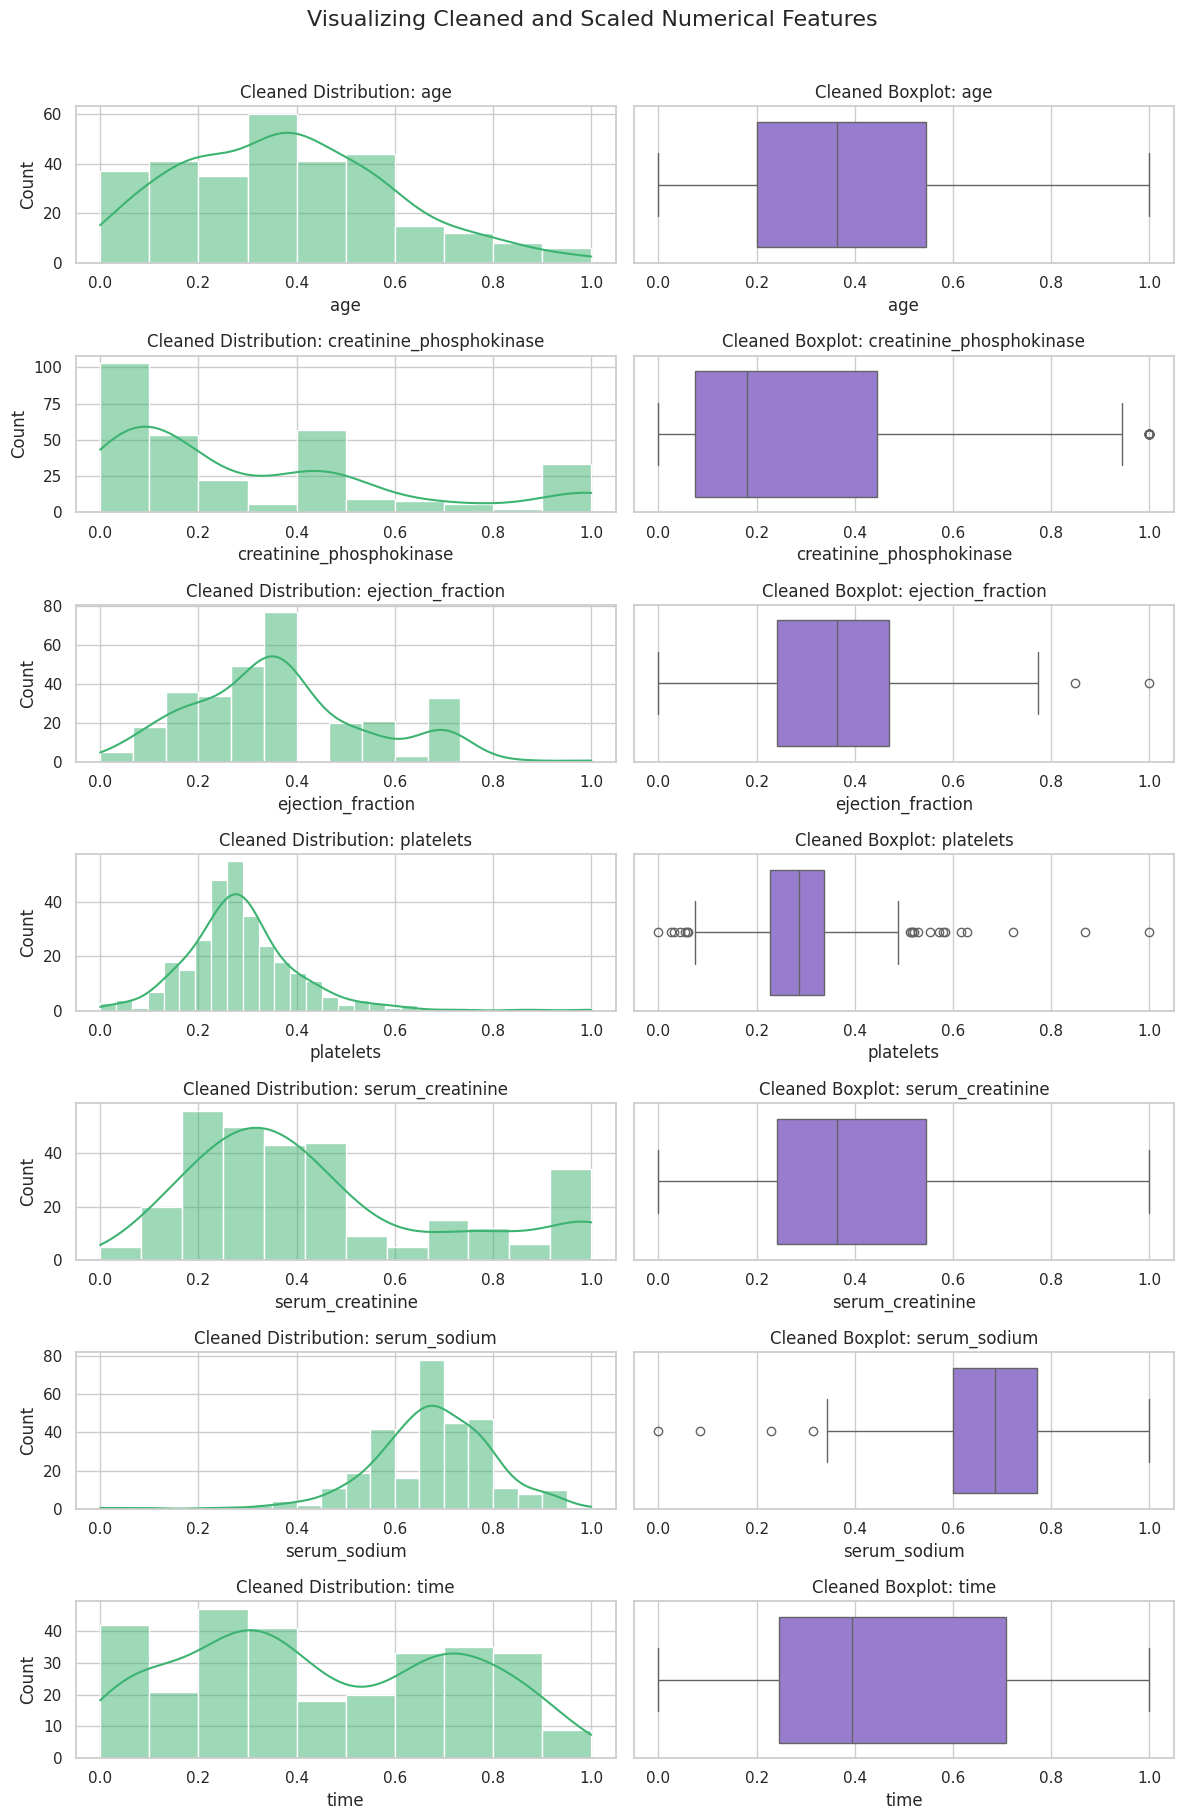

=== Task 14: Final Missing Value Check ===
Total Remaining Missing Values in Dataset: 0
 Validation Passed: The dataset contains zero missing values.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Set aesthetic styling for visualization
sns.set_theme(style="whitegrid")


# 1 & 2. Dataset Acquisition & Loading

file_path = "heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(file_path)

print("=== Task 2: First 5 Rows ===")
print(df.head())
print("\n" + "="*50 + "\n")


# 3. Summarize Dataset

print("=== Task 3: Dataset Summary ===")
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")

print("--- Data Types & Missing Values ---")
print(df.info())

print("\n--- Missing Value Counts per Column ---")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Calculate baseline summary statistics before cleaning
stats_before = df.describe().T[['mean', '50%', 'std']].rename(columns={'50%': 'median'})


# 4. Visualize Missing Values

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap (Before Imputation)", fontsize=14)
plt.tight_layout()
plt.show()


# 5. Plot Initial Distributions

num_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
            'platelets', 'serum_creatinine', 'serum_sodium', 'time']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 18))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f"Boxplot of {col}")

plt.suptitle("Initial Distributions & Outliers (Before Cleaning)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


# 6. Impute Missing Values


categorical_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if col in num_cols:
            # Use median for skewed clinical variables
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Imputed missing numerical values in '{col}' with median: {median_val}")
        else:
            # Use mode for binary/categorical features
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Imputed missing categorical values in '{col}' with mode: {mode_val}")


# 8. Correct Inconsistencies


print("=== Task 8: Inconsistency Check ===")
invalid_ages = df[df['age'] <= 0]
print(f"Invalid age entries (< 0): {len(invalid_ages)}")

# Fix negative values by taking the absolute value
df['age'] = df['age'].abs()

# Ensure percentages stay within [0, 100] range
df['ejection_fraction'] = df['ejection_fraction'].clip(lower=0, upper=100)


# 7. Remove/Handle Outliers


def cap_outliers_iqr(dataframe, columns):
    df_capped = dataframe.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Winsorize / Cap extreme outliers to upper and lower bounds
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    return df_capped

# Capping extreme clinical spikes without dropping critical rows
df = cap_outliers_iqr(df, ['serum_creatinine', 'creatinine_phosphokinase'])


# 9. Feature Engineering

# A. Create age_group bin feature
bins = [0, 40, 60, np.inf]
labels = ['<40', '40–60', '>60']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# B. Create risk_score feature
# Product of serum_creatinine and (100 - ejection_fraction), normalized between 0 and 1
raw_risk = df['serum_creatinine'] * (100 - df['ejection_fraction'])
scaler_risk = MinMaxScaler()
df['risk_score'] = scaler_risk.fit_transform(raw_risk.values.reshape(-1, 1))

print("=== Task 9: Engineered Features Sample ===")
print(df[['age', 'age_group', 'ejection_fraction', 'serum_creatinine', 'risk_score']].head())
print("\n" + "="*50 + "\n")


# 10. Encode Categorical Variables

# Map explicit string labels to binary for 'sex' if needed, then apply One-Hot Encoding on age_group
df = pd.get_dummies(df, columns=['age_group'], drop_first=False, dtype=int)


# 11. Normalize Features

# Scale continuous numerical features to range [0, 1] using MinMaxScaler
features_to_scale = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                     'platelets', 'serum_creatinine', 'serum_sodium', 'time']

min_max_scaler = MinMaxScaler()
df[features_to_scale] = min_max_scaler.fit_transform(df[features_to_scale])


# 12. Compute Summary Statistics

stats_after = df[features_to_scale].describe().T[['mean', '50%', 'std']].rename(columns={'50%': 'median'})

print("=== Task 12: Summary Statistics Comparison ===")
print("\n--- Statistics BEFORE Cleaning ---")
print(stats_before)

print("\n--- Statistics AFTER Cleaning & Normalization ---")
print(stats_after)
print("\n" + "="*50 + "\n")


# 13. Validate Cleaning (Plots)

fig, axes = plt.subplots(len(features_to_scale), 2, figsize=(12, 18))
for i, col in enumerate(features_to_scale):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='mediumseagreen')
    axes[i, 0].set_title(f"Cleaned Distribution: {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color='mediumpurple')
    axes[i, 1].set_title(f"Cleaned Boxplot: {col}")

plt.suptitle("Visualizing Cleaned and Scaled Numerical Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


# 14. Check Missing Values (Final Validation)

remaining_missing = df.isnull().sum().sum()

print("=== Task 14: Final Missing Value Check ===")
print(f"Total Remaining Missing Values in Dataset: {remaining_missing}")

if remaining_missing == 0:
    print(" Validation Passed: The dataset contains zero missing values.")
else:
    print(" Validation Warning: Some missing values remain. Review imputation steps.")